In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from Amaranta import ChiralTwin


## Data generation and save

In [3]:
sizes = [64, 128, 256, 512]
np.random.seed(0)

In [30]:
# Pure achiral
pure_achiral_64  = np.zeros((sizes[0], sizes[0]), dtype=int)
pure_achiral_128 = np.zeros((sizes[1], sizes[1]), dtype=int)
pure_achiral_256 = np.zeros((sizes[2], sizes[2]), dtype=int)
pure_achiral_512 = np.zeros((sizes[3], sizes[3]), dtype=int)

# np.save('../data/initial-conditions/pure_achiral_064.npy', pure_achiral_64)
# np.save('../data/initial-conditions/pure_achiral_128.npy', pure_achiral_128)
# np.save('../data/initial-conditions/pure_achiral_256.npy', pure_achiral_256)
# np.save('../data/initial-conditions/pure_achiral_512.npy', pure_achiral_512)


(64, 64)
(array([0, 1, 2]), array([3936,   84,   76]))



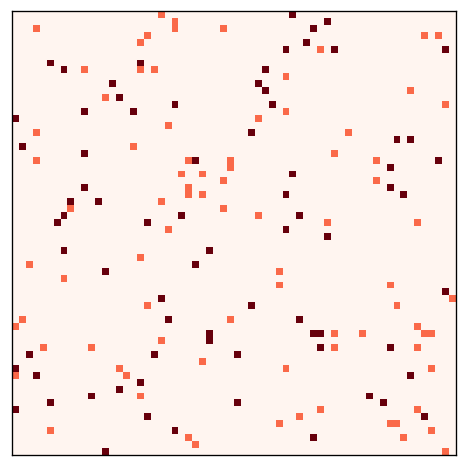

(128, 128)
(array([0, 1, 2]), array([15768,   293,   323]))



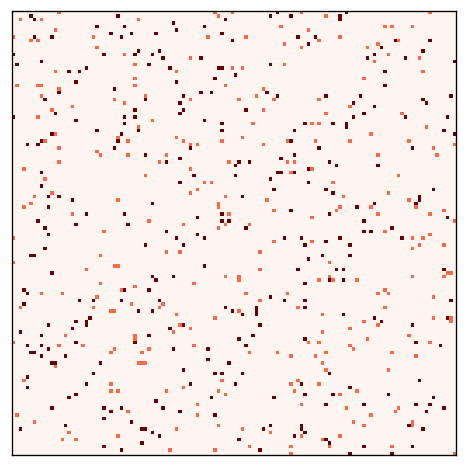

(256, 256)
(array([0, 1, 2]), array([62919,  1304,  1313]))



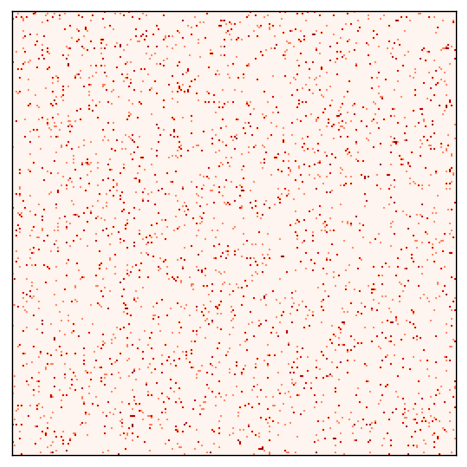

(512, 512)
(array([0, 1, 2]), array([251518,   5409,   5217]))



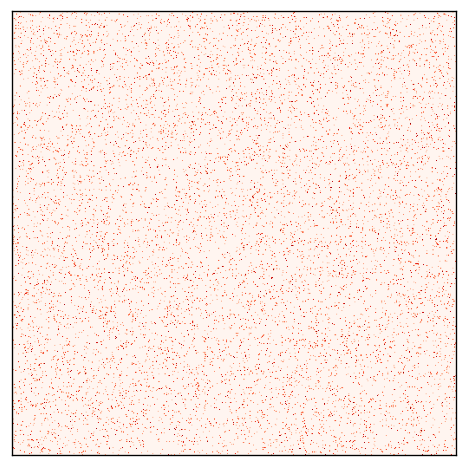

In [42]:
# Achiral majority
np.random.seed(1)
achiral_majority_64  = np.random.choice([0, 1, 2], size=(sizes[0], sizes[0]), p=[0.96, 0.02, 0.02])
achiral_majority_128 = np.random.choice([0, 1, 2], size=(sizes[1], sizes[1]), p=[0.96, 0.02, 0.02])
achiral_majority_256 = np.random.choice([0, 1, 2], size=(sizes[2], sizes[2]), p=[0.96, 0.02, 0.02])
achiral_majority_512 = np.random.choice([0, 1, 2], size=(sizes[3], sizes[3]), p=[0.96, 0.02, 0.02])

achiral_maj_data = [
    achiral_majority_64, 
    achiral_majority_128, 
    achiral_majority_256, 
    achiral_majority_512
    ]

for i in achiral_maj_data:
    print(i.shape)
    print(f"{np.unique(i, return_counts = True)}")
    print()
    plt.figure(dpi=120)
    plt.imshow(i, cmap="Reds", vmax = 2)
    plt.xticks([])
    plt.yticks([])
    plt.show()

# np.save("../data/initial-conditions/achiral_majority_064.npy", achiral_majority_64)
# np.save("../data/initial-conditions/achiral_majority_128.npy", achiral_majority_128)
# np.save("../data/initial-conditions/achiral_majority_256.npy", achiral_majority_256)
# np.save("../data/initial-conditions/achiral_majority_512_more2s.npy", achiral_majority_512) # seed 0
# np.save("../data/initial-conditions/achiral_majority_512_more1s.npy", achiral_majority_512) # seed 1

(64, 64)
(array([0, 1, 2]), array([3710,  193,  193]))



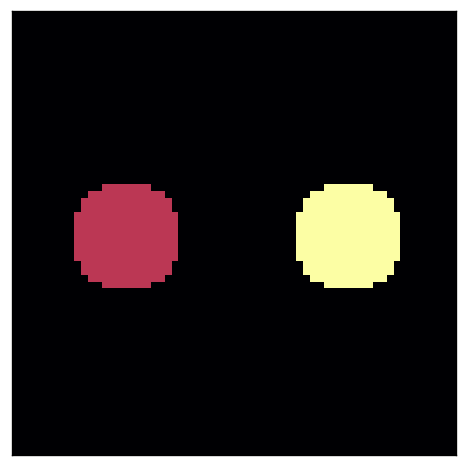

(128, 128)
(array([0, 1, 2]), array([14798,   793,   793]))



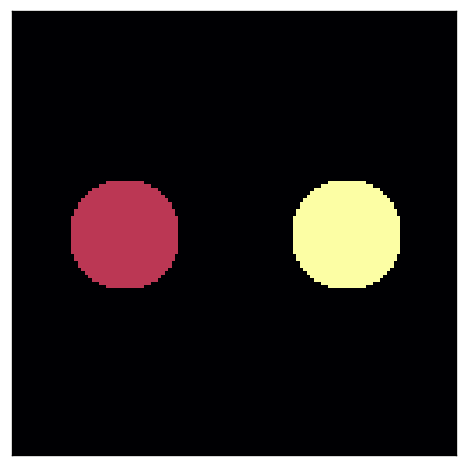

(256, 256)
(array([0, 1, 2]), array([59126,  3205,  3205]))



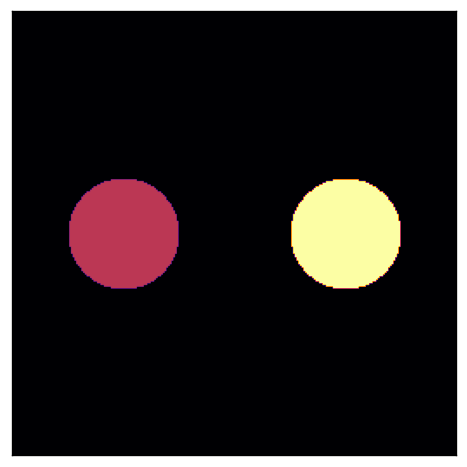

(512, 512)
(array([0, 1, 2]), array([236446,  12849,  12849]))



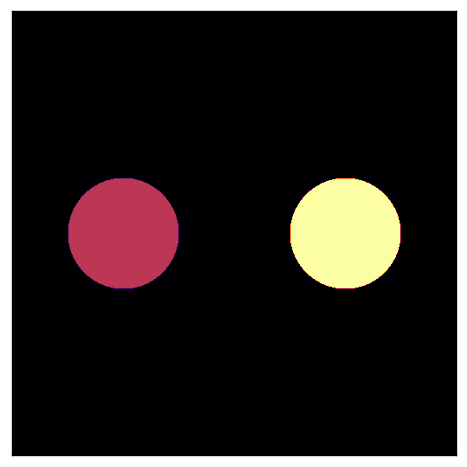

In [15]:
# Blobs
ic_blobs_64  = np.zeros((sizes[0], sizes[0]), dtype=int)
ic_blobs_128 = np.zeros((sizes[1], sizes[1]), dtype=int)
ic_blobs_256 = np.zeros((sizes[2], sizes[2]), dtype=int)
ic_blobs_512 = np.zeros((sizes[3], sizes[3]), dtype=int)

cx, cy = sizes[0] // 2, sizes[0] // 2
r = sizes[0] // 8
for i in range(sizes[0]):
    for j in range(sizes[0]):
        if np.sqrt((i - cx)**2 + (j - sizes[0]//4)**2) < r:
            ic_blobs_64[i, j] = 1
        elif np.sqrt((i - cx)**2 + (j - 3*sizes[0]//4)**2) < r:
            ic_blobs_64[i, j] = 2

cx, cy = sizes[1] // 2, sizes[1] // 2
r = sizes[1] // 8
for i in range(sizes[1]):
    for j in range(sizes[1]):
        if np.sqrt((i - cx)**2 + (j - sizes[1]//4)**2) < r:
            ic_blobs_128[i, j] = 1
        elif np.sqrt((i - cx)**2 + (j - 3*sizes[1]//4)**2) < r:
            ic_blobs_128[i, j] = 2

cx, cy = sizes[2] // 2, sizes[2] // 2
r = sizes[2] // 8
for i in range(sizes[2]):
    for j in range(sizes[2]):
        if np.sqrt((i - cx)**2 + (j - sizes[2]//4)**2) < r:
            ic_blobs_256[i, j] = 1
        elif np.sqrt((i - cx)**2 + (j - 3*sizes[2]//4)**2) < r:
            ic_blobs_256[i, j] = 2

cx, cy = sizes[3] // 2, sizes[3] // 2
r = sizes[3] // 8
for i in range(sizes[3]):
    for j in range(sizes[3]):
        if np.sqrt((i - cx)**2 + (j - sizes[3]//4)**2) < r:
            ic_blobs_512[i, j] = 1
        elif np.sqrt((i - cx)**2 + (j - 3*sizes[3]//4)**2) < r:
            ic_blobs_512[i, j] = 2

for ic in [ic_blobs_64, ic_blobs_128, ic_blobs_256, ic_blobs_512]:
    print(ic.shape)
    print(f"{np.unique(ic, return_counts = True)}")
    print()
    plt.figure(dpi=120)
    plt.imshow(ic, cmap="inferno", vmax = 2)
    plt.xticks([])
    plt.yticks([])
    plt.show()

np.save("../data/initial-conditions/blobs_064.npy", ic_blobs_64)
np.save("../data/initial-conditions/blobs_128.npy", ic_blobs_128)
np.save("../data/initial-conditions/blobs_256.npy", ic_blobs_256)
np.save("../data/initial-conditions/blobs_512.npy", ic_blobs_512)

## Simulation

In [32]:
config = {
    'simulation': {
        'total_steps': 500,
        'boundary_condition': 'periodic',
        'save_evolution': False,
        'save_images': False
    },
    'probs': {
        'dist_type': 'uniform',
        'seed': 12,
        'p_neutral': 0.05,
        'p_chiral': 0.1,
        'p_copy': 0.2,
    },
    'chaos': {
        'mode': 'constant',

        'constant': {
            'epsilon': 1.0
        },

        'pulse': {
            'start_step': 30,
            'end_step': 60,
            'magnitude': 0.5
        },

        'linear': {
            'start_epsilon': 0.0,
            'end_epsilon': 10.0
        }
    }
}

### Pure achiral diagnosis

In [ ]:
data = pure_achiral_64

twin                = ChiralTwin(data, config = config)
list0, list1, list2 = twin.timeEvolution()

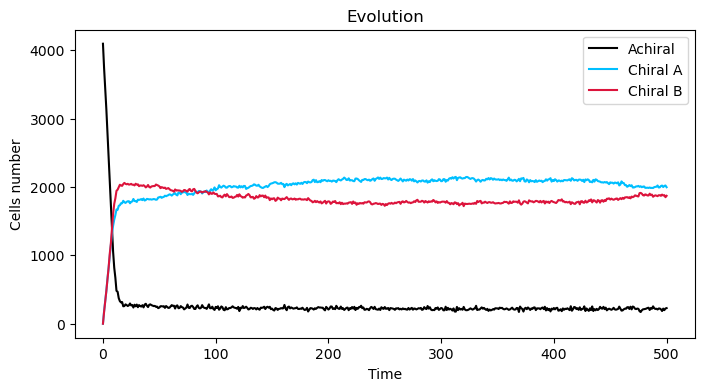

In [29]:
plt.figure(figsize=(8,4), dpi=100)
plt.plot(list0, label='Achiral', color='k')
plt.plot(list1, label='Chiral A', color='deepskyblue')
plt.plot(list2, label='Chiral B', color='crimson')
plt.xlabel('Time')
plt.ylabel('Cells number')
plt.title('Evolution')
# plt.ylim(0)
plt.legend()
plt.show()

### Achiral majority diagnosis

In [35]:
data = achiral_majority_64

twin                = ChiralTwin(data, config = config)
list0, list1, list2 = twin.timeEvolution()

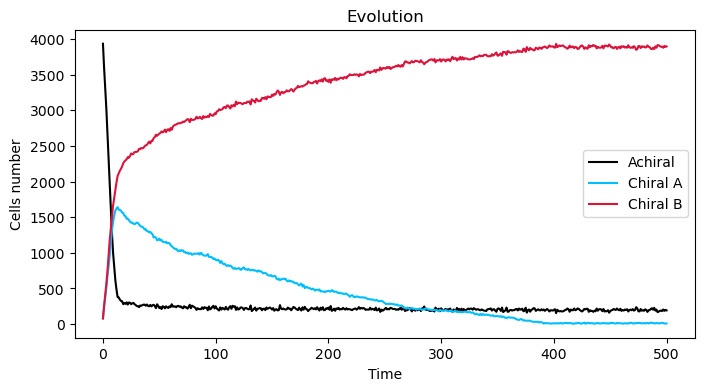

In [36]:
plt.figure(figsize=(8,4), dpi=100)
plt.plot(list0, label='Achiral', color='k')
plt.plot(list1, label='Chiral A', color='deepskyblue')
plt.plot(list2, label='Chiral B', color='crimson')
plt.xlabel('Time')
plt.ylabel('Cells number')
plt.title('Evolution')
# plt.ylim(0)
plt.legend()
plt.show()

In [39]:
print(f"Initial chiral A: {list1[0]}, Initial chiral B: {list2[0]}")

Initial chiral A: 84, Initial chiral B: 76


### Blobs diagnosis

In [40]:
data = ic_blobs_64

twin                = ChiralTwin(data, config = config)
list0, list1, list2 = twin.timeEvolution()

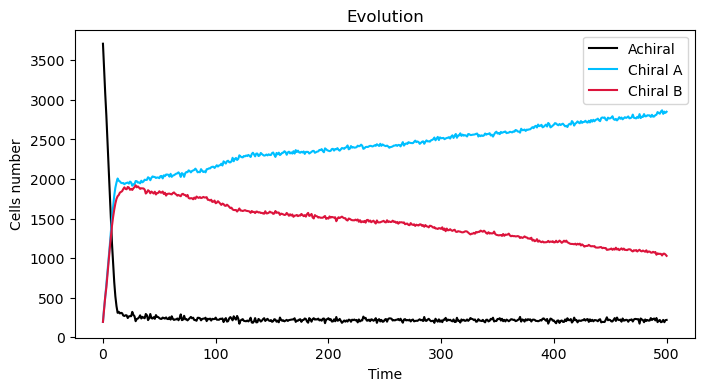

In [41]:
plt.figure(figsize=(8,4), dpi=100)
plt.plot(list0, label='Achiral', color='k')
plt.plot(list1, label='Chiral A', color='deepskyblue')
plt.plot(list2, label='Chiral B', color='crimson')
plt.xlabel('Time')
plt.ylabel('Cells number')
plt.title('Evolution')
# plt.ylim(0)
plt.legend()
plt.show()